# Dataset Extraction: Bitcoin (BTC-USD)

In [1]:

# Time period: August 2014 to December 2025

import yfinance as yf
import pandas as pd

# Define ticker and date range
ticker = "BTC-USD"
start_date = "2014-08-01"
end_date = "2025-12-31"

# Download data
df = yf.download(ticker, start=start_date, end=end_date)

# Reset index to make Date a column
df.reset_index(inplace=True)

# Save to CSV
file_name = "BTC_USD_Aug2014_Dec2025.csv"
df.to_csv(file_name, index=False)

# Basic info check
print("Dataset downloaded successfully!")
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Shape:", df.shape)
print(df.head())


/tmp/ipython-input-1526363275.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Dataset downloaded successfully!
Date range: 2014-09-17 00:00:00 to 2025-12-30 00:00:00
Shape: (4123, 6)
Price        Date       Close        High         Low        Open    Volume
Ticker                BTC-USD     BTC-USD     BTC-USD     BTC-USD   BTC-USD
0      2014-09-17  457.334015  468.174011  452.421997  465.864014  21056800
1      2014-09-18  424.440002  456.859985  413.104004  456.859985  34483200
2      2014-09-19  394.795990  427.834991  384.532013  424.102997  37919700
3      2014-09-20  408.903992  423.295990  389.882996  394.673004  36863600
4      2014-09-21  398.821014  412.425995  393.181000  408.084991  26580100


Load Dataset & Basic Inspection

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV, skip the second header row
df = pd.read_csv(
    "BTC_USD_Aug2014_Dec2025.csv",
    skiprows=[1]  # removes the BTC-USD row
)

# Rename columns cleanly (safety)
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Sort data by date (important for time-series analysis)
df = df.sort_values("Date").reset_index(drop=True)

# Drop missing values
df = df.dropna()

print(df.head())
print(df.info())


        Date       Close        High         Low        Open    Volume
0 2014-09-17  457.334015  468.174011  452.421997  465.864014  21056800
1 2014-09-18  424.440002  456.859985  413.104004  456.859985  34483200
2 2014-09-19  394.795990  427.834991  384.532013  424.102997  37919700
3 2014-09-20  408.903992  423.295990  389.882996  394.673004  36863600
4 2014-09-21  398.821014  412.425995  393.181000  408.084991  26580100
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4123 entries, 0 to 4122
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    4123 non-null   datetime64[ns]
 1   Close   4123 non-null   float64       
 2   High    4123 non-null   float64       
 3   Low     4123 non-null   float64       
 4   Open    4123 non-null   float64       
 5   Volume  4123 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 193.4 KB
None


Missing Values & Data Quality Check

In [3]:
# Check missing values
missing = df.isnull().sum()
print("Missing values:\n", missing)

# If needed (usually Yahoo Finance is clean)
df = df.dropna()


Missing values:
 Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


Exploratory Data Analysis

Time Series Plot (Close Price)

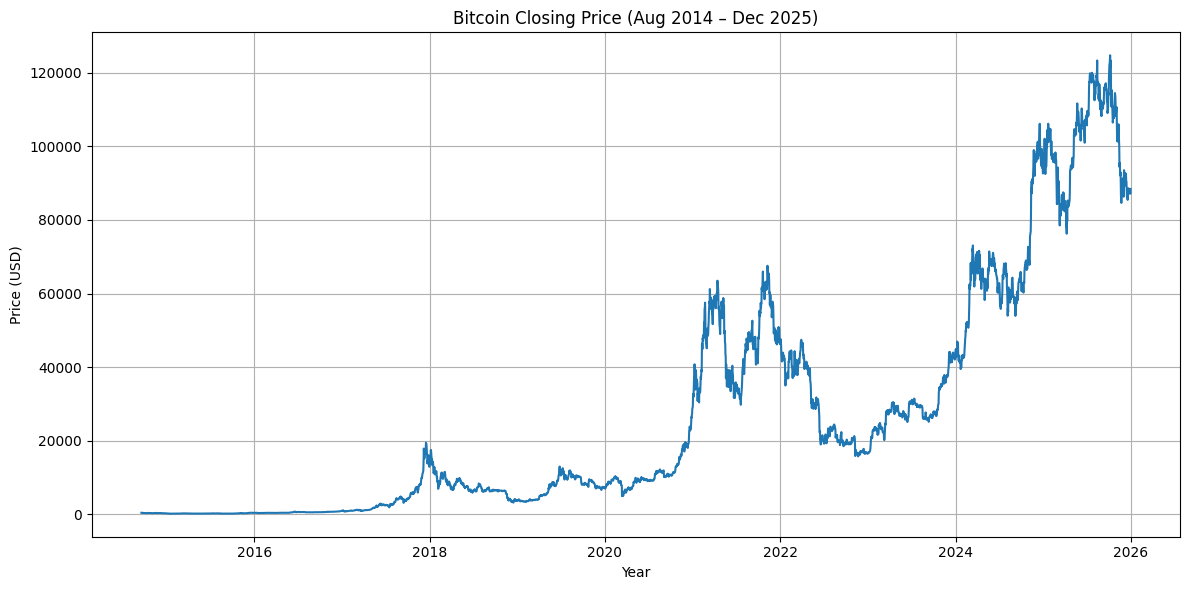

In [4]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title("Bitcoin Closing Price (Aug 2014 – Dec 2025)")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.grid(True)
plt.show()


Feature Distribution

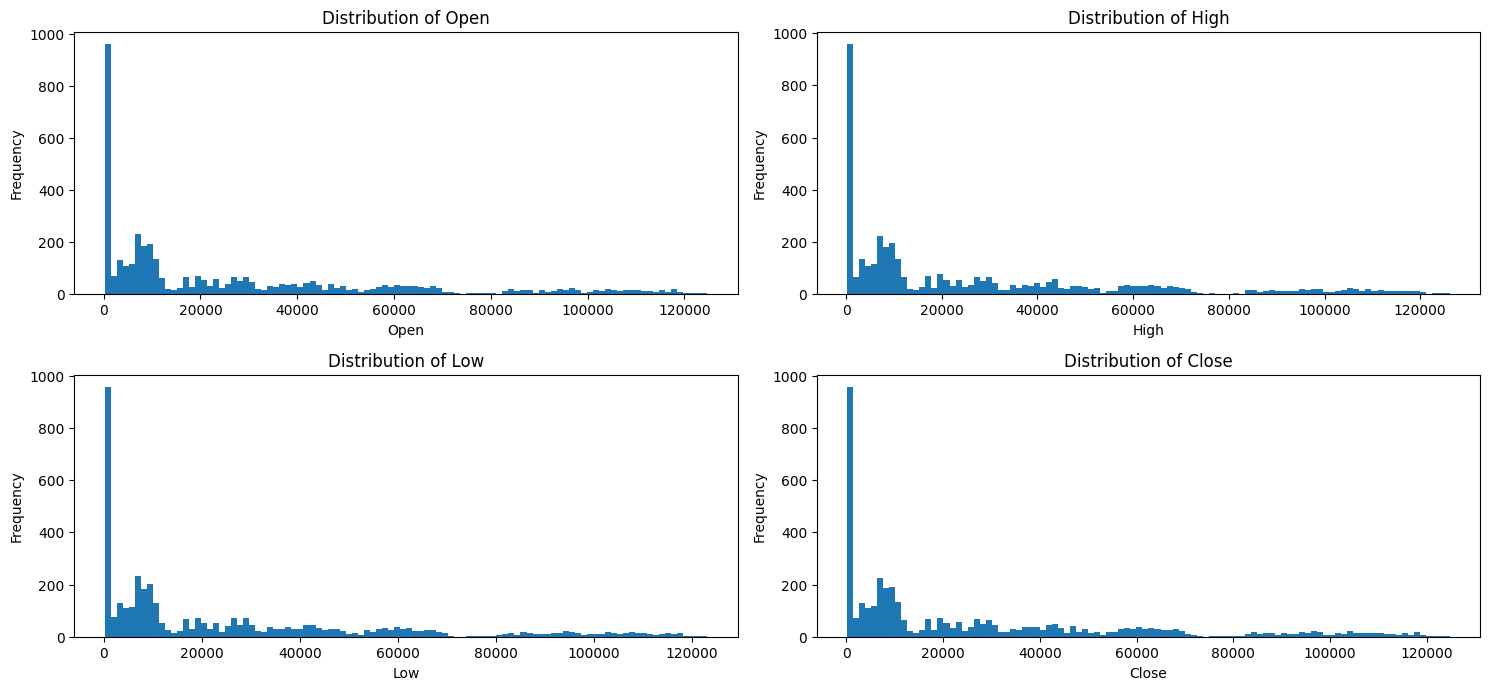

In [5]:
features = ['Open', 'High', 'Low', 'Close']

plt.figure(figsize=(15,10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 2, i)
    plt.hist(df[col], bins=100)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


Box Plots – ALL Features (Outliers & Spread)

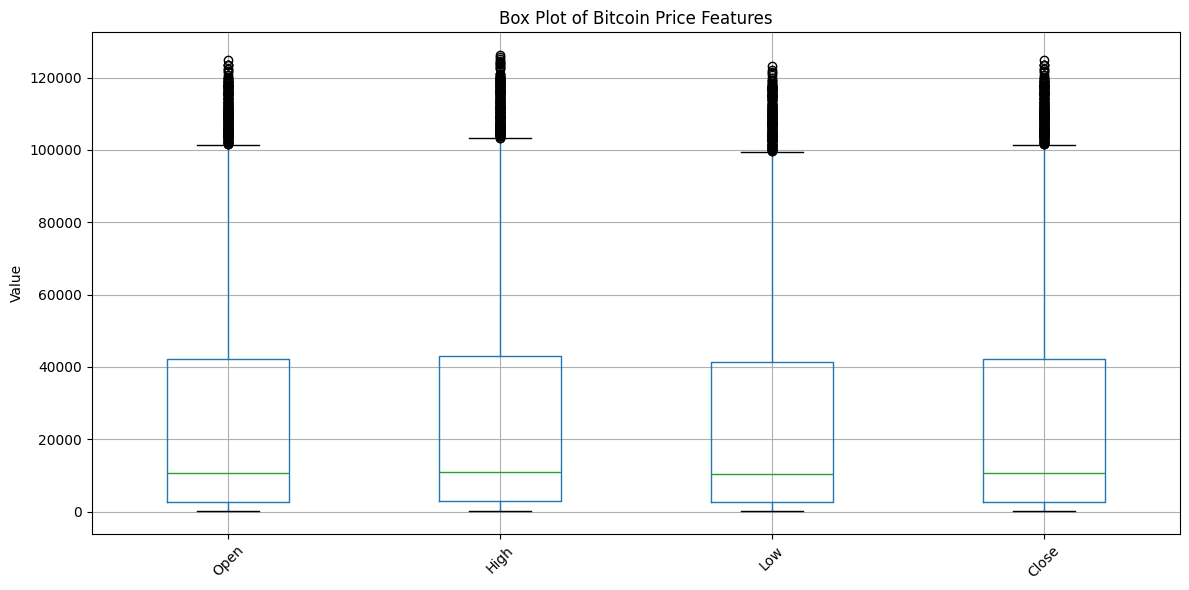

In [6]:
plt.figure(figsize=(12,6))
df[features].boxplot()
plt.title("Box Plot of Bitcoin Price Features")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


There are so many outliers in the data which means that the prices of the stock have varied hugely in a very short period of time.Let's check this with the help of a barplot.


#Feature Engineering

Feature Engineering helps to derive some valuable features from the existing ones. These extra features sometimes help in increasing the performance of the model significantly and certainly help to gain deeper insights into the data.

In [7]:
# Extract Year, Month, and Day from Date
# Feature engineering from Date
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

df.head()

,Date,Close,High,Low,Open,Volume,year,month,day
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,2014,9,17
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,2014,9,18
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,2014,9,19
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,2014,9,20
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,2014,9,21


Year-wise Aggregation (Mean Prices)

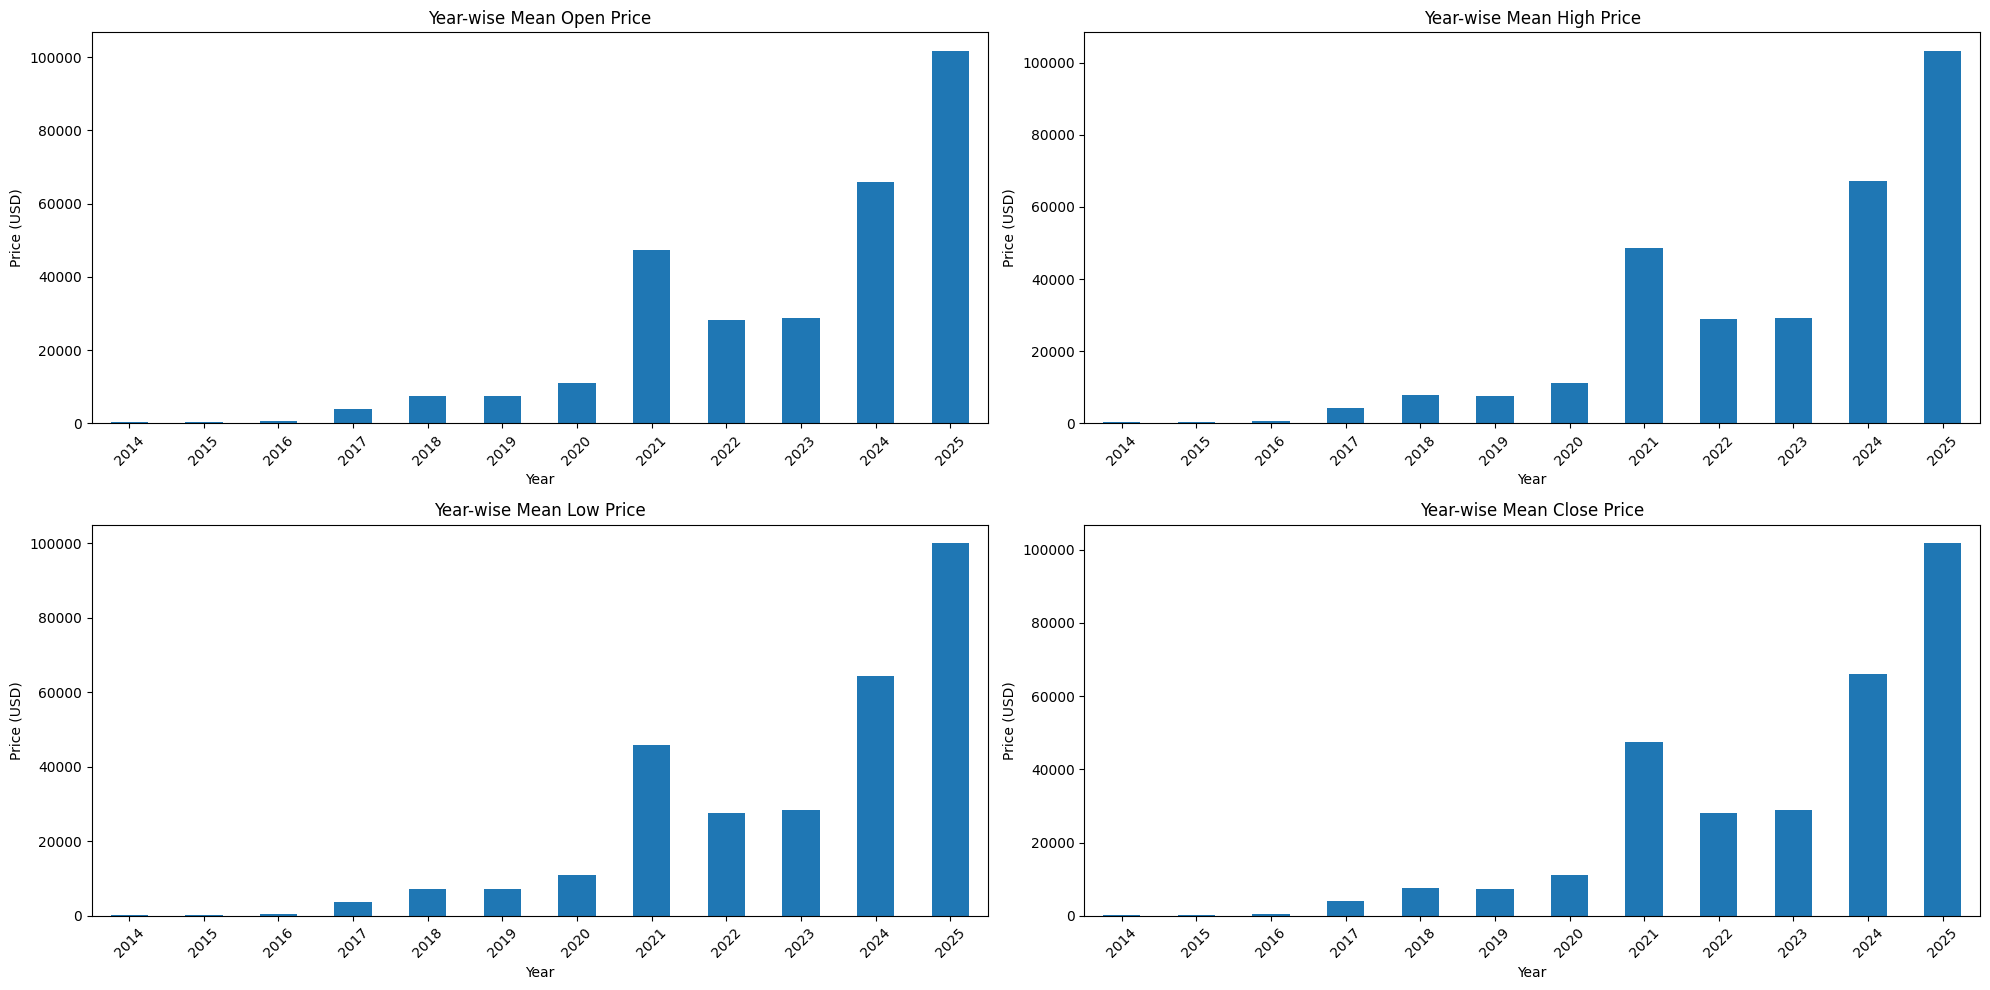

In [8]:
# Group by year and calculate mean
data_grouped = df.groupby('year')[['Open', 'High', 'Low', 'Close']].mean()

# Plot year-wise mean prices
plt.figure(figsize=(20,10))

for i, col in enumerate(['Open', 'High', 'Low', 'Close'], 1):
    plt.subplot(2, 2, i)
    data_grouped[col].plot(kind='bar')
    plt.title(f"Year-wise Mean {col} Price")
    plt.xlabel("Year")
    plt.ylabel("Price (USD)")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


The year-wise mean price analysis reveals a sharp increase in Bitcoin prices from 2020 onwards, with a significant price surge observed during 2021 and subsequent years. This rapid growth explains the presence of extreme outliers identified in the box plots and distribution analysis. The results indicate that these outliers are not data errors but reflect genuine market behaviour driven by large-scale price appreciation.

Correlation Heatmap (Price Features)

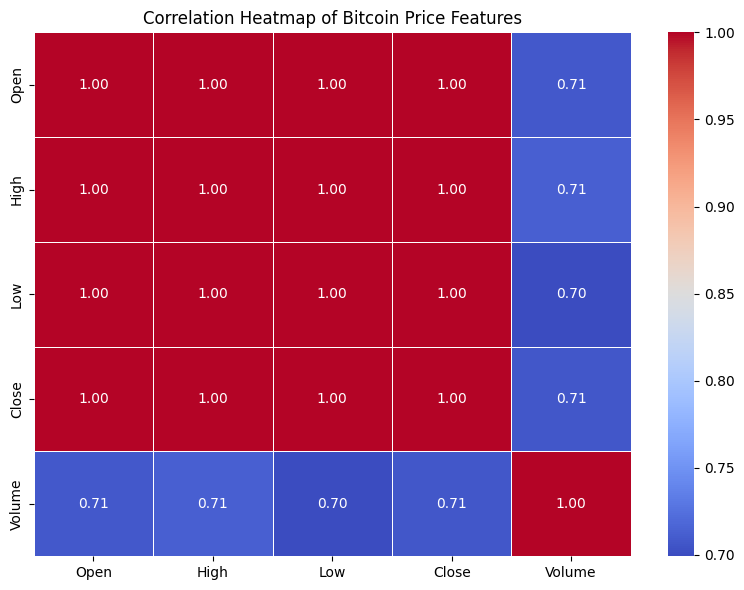

In [10]:
import seaborn as sns

# Select relevant numerical features
features = ['Open', 'High', 'Low', 'Close', 'Volume']

# Compute correlation matrix
corr_matrix = df[features].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Bitcoin Price Features")
plt.tight_layout()
plt.show()


The correlation heatmap shows near-perfect positive correlations among Open, High, Low, and Close prices, indicating strong multicollinearity between price-based features. This behaviour is expected in financial time-series data, as these variables represent different price points within the same trading period. Trading volume exhibits a comparatively lower correlation with price features, suggesting that it may provide complementary market activity information rather than direct price dependence.